<a href="https://colab.research.google.com/github/dipsom247-svg/Airline-Cargo-Operations-Performance-Analysis/blob/main/01_EDA_Cargo_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Airline Cargo Demand Forecasting using EDA, Machine Learning and Deep Learning

## Exploratory Data Analysis (EDA)

Author: Dipanjan Bhowmick

Domain: Airline Cargo Operations

Objective:
To analyze airline cargo operations data and identify factors influencing cargo demand, aircraft utilization, revenue generation, and operational efficiency.

In [3]:
#Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

%matplotlib inline

In [4]:
#Load Dataset
df = pd.read_csv('cargo_operations_5000.csv')

df.head()

,Date,Flight_No,Origin,Destination,Aircraft_Type,Capacity_KG,Booked_KG,Loaded_KG,Offloaded_KG,Revenue_INR,Delay_Minutes
0,2025-01-17,AI200,CCU,BLR,A321,20000,13000,12235,765,647618,71
1,2025-03-21,AI201,DEL,HYD,A320,18000,14900,14145,755,694364,28
2,2025-01-23,AI202,BOM,BLR,B787,35000,28030,26632,1398,1624948,9
3,2025-04-16,AI203,DEL,BOM,B787,35000,33082,30632,2450,1414734,72
4,2025-09-18,AI204,CCU,BLR,A321,20000,15717,14676,1041,702135,26


In [5]:
#Dataset Overview
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

df.info()

Rows : 5000
Columns : 11
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Date           5000 non-null   object
 1   Flight_No      5000 non-null   object
 2   Origin         5000 non-null   object
 3   Destination    5000 non-null   object
 4   Aircraft_Type  5000 non-null   object
 5   Capacity_KG    5000 non-null   int64 
 6   Booked_KG      5000 non-null   int64 
 7   Loaded_KG      5000 non-null   int64 
 8   Offloaded_KG   5000 non-null   int64 
 9   Revenue_INR    5000 non-null   int64 
 10  Delay_Minutes  5000 non-null   int64 
dtypes: int64(6), object(5)
memory usage: 429.8+ KB


In [6]:
#Missing Values
df.isnull().sum()

,0
Date,0
Flight_No,0
Origin,0
Destination,0
Aircraft_Type,0
Capacity_KG,0
Booked_KG,0
Loaded_KG,0
Offloaded_KG,0
Revenue_INR,0


#Observation
#No significant missing values were found in the dataset.

In [7]:
#Duplicate Records
df.duplicated().sum()

np.int64(0)

In [8]:
df.drop_duplicates(inplace=True)

In [10]:
#Statistical Summary
df.describe()

,Capacity_KG,Booked_KG,Loaded_KG,Offloaded_KG,Revenue_INR,Delay_Minutes
count,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.000000
mean,22273.800000,18164.840200,17342.237000,822.603200,9.533862e+05,44.875400
std,6508.587089,5784.987291,5535.614638,467.847009,3.221792e+05,26.456959
min,18000.000000,11703.000000,10894.000000,128.000000,4.935150e+05,0.000000
25%,18000.000000,14283.500000,13605.750000,471.000000,7.328072e+05,22.000000
50%,20000.000000,16246.500000,15530.500000,755.000000,8.506185e+05,45.000000
75%,20000.000000,18833.250000,17924.750000,1054.250000,1.039239e+06,69.000000
max,35000.000000,34298.000000,33910.000000,2639.000000,2.133883e+06,89.000000


**KPI Creation**

In [13]:
#Load Factor
df['Load_Factor'] = (
    df['Loaded_KG']
    /
    df['Capacity_KG']
) * 100

In [14]:
#Utilization
df['Utilization'] = (
    df['Booked_KG']
    /
    df['Capacity_KG']
) * 100

In [15]:
#Offload Percentage
df['Offload_Percentage'] = (
    df['Offloaded_KG']
    /
    df['Booked_KG']
) * 100

In [16]:
#Revenue Per KG
df['Revenue_Per_KG'] = (
    df['Revenue_INR']
    /
    df['Loaded_KG']
)

In [17]:
# KPI Dashboard
print("Average Load Factor :", round(df['Load_Factor'].mean(),2))

print("Average Utilization :", round(df['Utilization'].mean(),2))

print("Average Offload % :", round(df['Offload_Percentage'].mean(),2))

print("Total Revenue :", round(df['Revenue_INR'].sum()))

Average Load Factor : 77.82
Average Utilization : 81.52
Average Offload % : 4.52
Total Revenue : 4766931112


**EDA Visualizations**

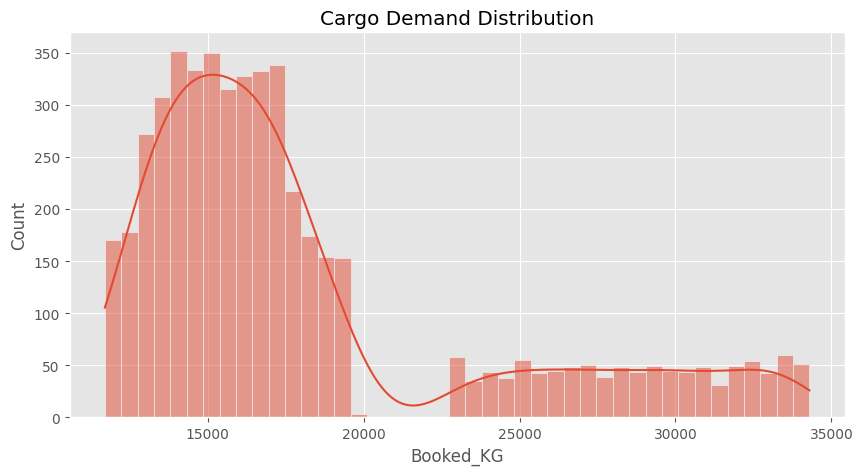

In [18]:
#Chart 1 Cargo Demand Distribution
plt.figure(figsize=(10,5))

sns.histplot(
    df['Booked_KG'],
    kde=True
)

plt.title('Cargo Demand Distribution')

plt.show()

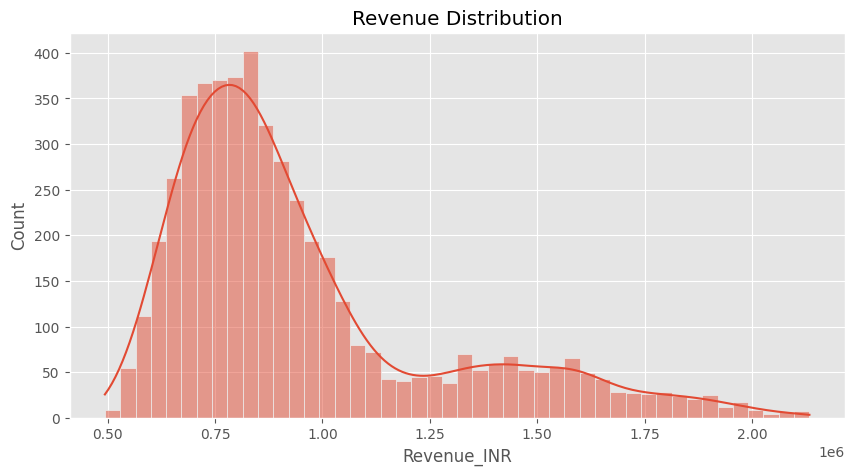

In [19]:
#Chart 2 Revenue Distribution
plt.figure(figsize=(10,5))

sns.histplot(
    df['Revenue_INR'],
    kde=True
)

plt.title('Revenue Distribution')

plt.show()

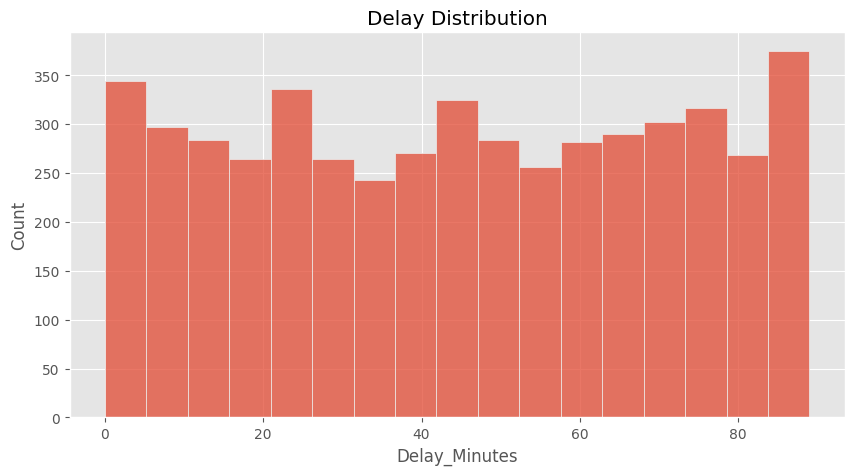

In [20]:
#Chart 3 Delay Distribution
plt.figure(figsize=(10,5))

sns.histplot(
    df['Delay_Minutes']
)

plt.title('Delay Distribution')

plt.show()

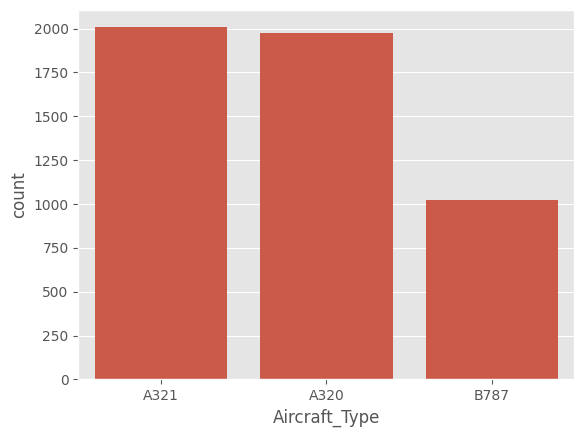

In [21]:
#Chart 4 Aircraft Type Count
sns.countplot(
    x='Aircraft_Type',
    data=df
)

plt.show()

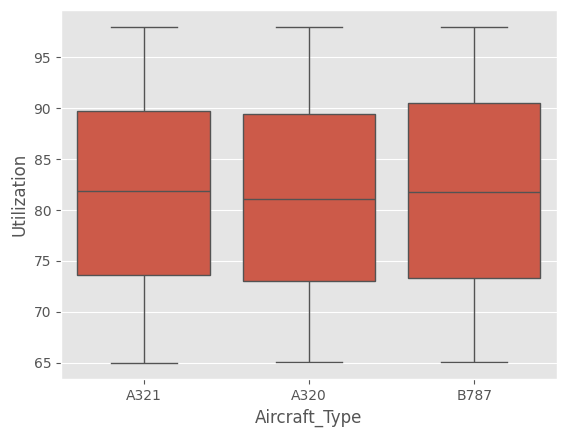

In [22]:
#Chart 5 Aircraft Utilization
sns.boxplot(
    x='Aircraft_Type',
    y='Utilization',
    data=df
)

plt.show()

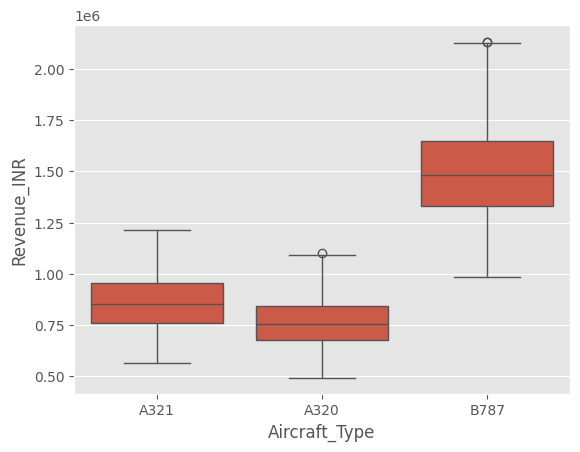

In [23]:
#Chart 6 Revenue by Aircraft
sns.boxplot(
    x='Aircraft_Type',
    y='Revenue_INR',
    data=df
)

plt.show()

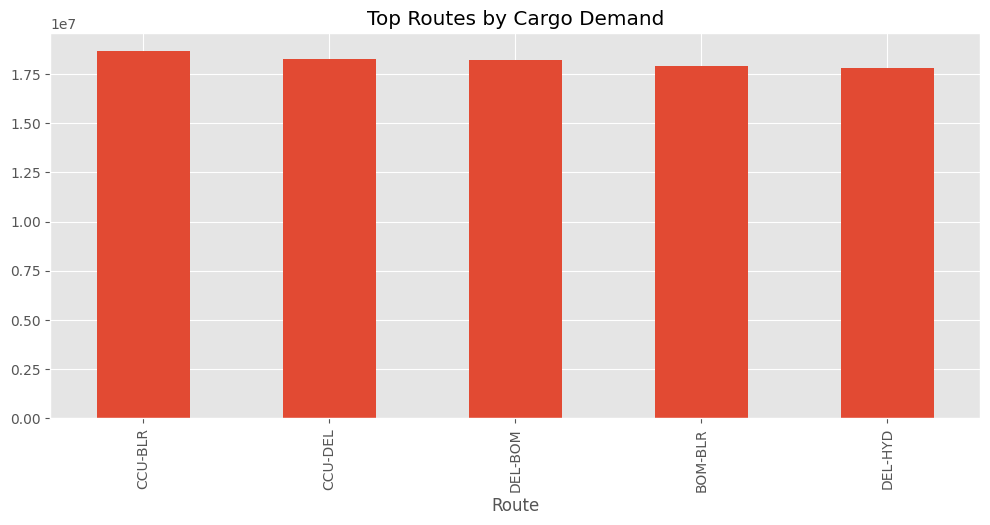

In [25]:
#Chart 7 Route Analysis
df['Route'] = (
    df['Origin']
    +
    '-'
    +
    df['Destination']
)

route_demand = df.groupby(
    'Route'
)['Booked_KG'].sum().sort_values(
    ascending=False
)

route_demand.head(10).plot(
    kind='bar',
    figsize=(12,5)
)

plt.title('Top Routes by Cargo Demand')

plt.show()

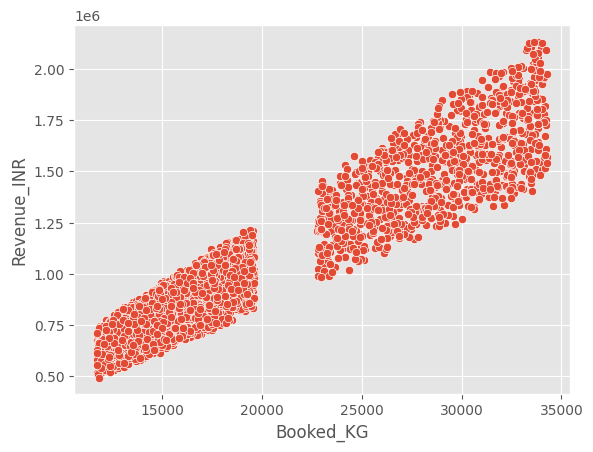

In [26]:
#Chart 8 Revenue vs Cargo Demand
sns.scatterplot(
    x='Booked_KG',
    y='Revenue_INR',
    data=df
)

plt.show()

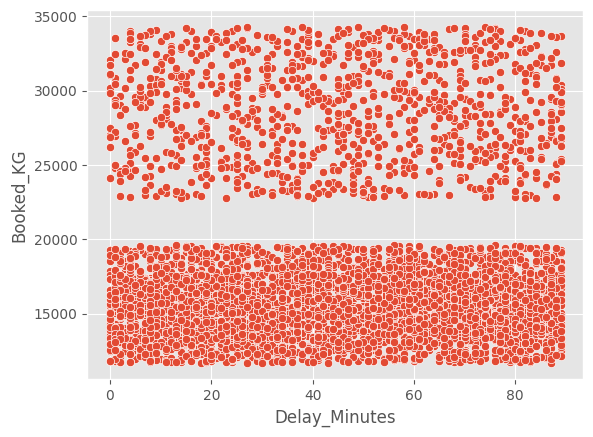

In [27]:
#Chart 9 Delay vs Demand
sns.scatterplot(
    x='Delay_Minutes',
    y='Booked_KG',
    data=df
)

plt.show()

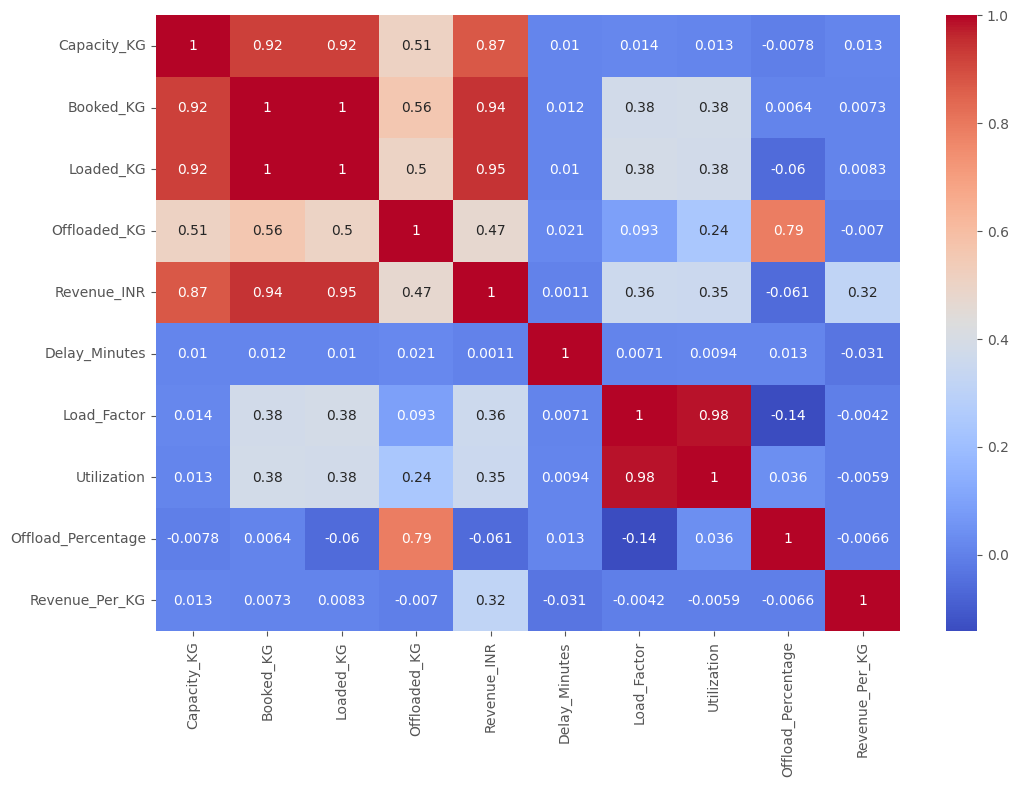

In [28]:
#Chart 10 Correlation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

**Business Insights**
1. Aircraft capacity strongly influences cargo demand.

2. Revenue is positively correlated with booked cargo volume.

3. Certain routes consistently generate higher cargo demand.

4. Delay impacts operational efficiency and cargo movement.

5. Aircraft utilization above 85% provides maximum operational benefit.

**Conclusion**:
The EDA reveals significant relationships between cargo demand, revenue generation, aircraft utilization, and operational delays.

These insights provide a foundation for predictive modeling using Machine Learning and Deep Learning techniques.